In [49]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import imghdr
import json
import pytesseract
from PIL import Image, ImageChops

In [50]:
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [ ]:
def load_image(path):
    file_type = imghdr.what(path)
    if file_type not in ["jpeg", "png", "jpg"]:
        raise ValueError("Invalid file type. Only jpeg/png/jpg allowed.")
    img = cv2.imread(path)
    return img

img_path = "id image.jpg" 
img = load_image(img_path)

In [52]:
def analyze_image(img):
    h, w = img.shape[:2]
    results = {
        "resolution": f"{w}x{h}",
        "low_resolution_flag": bool(w < 500 or h < 500)
    }
    edges = cv2.Canny(img, 100, 200)
    edge_density = float(np.sum(edges) / (w * h))
    results["edge_density"] = edge_density
    results["suspicious_edges_flag"] = bool(edge_density > 0.05)
    mean, stddev = cv2.meanStdDev(img)
    results["color_stddev"] = [float(x) for x in stddev.flatten()]
    results["color_inconsistency_flag"] = bool(any(s > 60 for s in stddev.flatten()))
    return results

image_results = analyze_image(img)

In [53]:
def extract_text(img):
    pil_img = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    return pytesseract.image_to_string(pil_img)

text_output = extract_text(img)
print("Extracted Text:\n", text_output)

Extracted Text:
 DRIVER LICENSE

ID 1234567890 é
NAME SURNAME

11.08.1990 11.08.2020
11.08.2030




In [54]:
def analyze_text(text):
    return {
        "text_length": int(len(text.strip())),
        "contains_id_number": bool(any(char.isdigit() for char in text)),
        "suspicious_text_flag": bool(len(text.strip()) < 20)
    }

text_results = analyze_text(text_output)

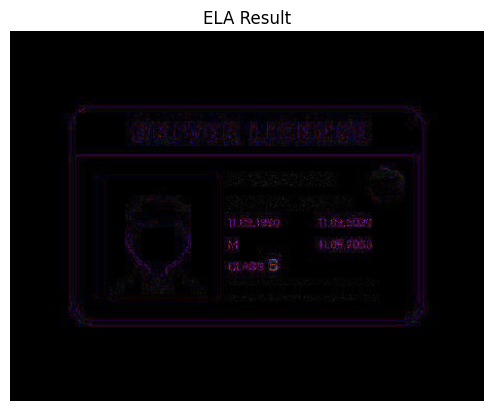

In [ ]:
def perform_ela(img_path, quality=90):
    original = Image.open(img_path).convert("RGB")
    temp_path = "temp_ela.jpg"
    original.save(temp_path, "JPEG", quality=quality)
    recompressed = Image.open(temp_path)
    diff = ImageChops.difference(original, recompressed)
    extrema = diff.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    scale = 255.0 / max_diff if max_diff != 0 else 1
    ela_image = diff.point(lambda x: x * scale)
    return ela_image

ela_result = perform_ela(img_path)
plt.imshow(ela_result)
plt.title("ELA Result")
plt.axis("off")
plt.show()


ela_flag = True   

In [56]:
def generate_report(image_results, text_results, ela_flag=False):
    risk_score = sum([
        image_results["low_resolution_flag"],
        image_results["suspicious_edges_flag"],
        image_results["color_inconsistency_flag"],
        text_results["suspicious_text_flag"],
        ela_flag
    ])
    return {
        "Forgery Risk Report": {
            "Image Analysis": image_results,
            "Text Analysis": text_results,
            "ELA Flag": ela_flag,
            "Overall Risk": "Suspicious" if risk_score >= 2 else "Likely Genuine"
        }
    }

final_report = generate_report(image_results, text_results, ela_flag)

In [57]:
print(json.dumps(final_report, indent=4))

with open("fraud_report.json", "w") as f:
    json.dump(final_report, f, indent=4)

print("Report saved as fraud_report.json")

{
    "Forgery Risk Report": {
        "Image Analysis": {
            "resolution": "461x360",
            "low_resolution_flag": true,
            "edge_density": 10.944595083152567,
            "suspicious_edges_flag": true,
            "color_stddev": [
                41.75704680212879,
                56.45050605600119,
                69.2738496049912
            ],
            "color_inconsistency_flag": true
        },
        "Text Analysis": {
            "text_length": 78,
            "contains_id_number": true,
            "suspicious_text_flag": false
        },
        "ELA Flag": true,
        "Overall Risk": "Suspicious"
    }
}
Report saved as fraud_report.json


In [58]:
with open("fraud_report.json", "w") as f:
    json.dump(final_report, f, indent=4)

print("Report saved as fraud_report.json")

Report saved as fraud_report.json
